# Used Car Price Prediction — Deep Learning Regression
**Milestone 2 | Realistic Dataset Edition**

Dataset: **used_cars_realistic.csv** — 3,000 real-world-style listings across 10 brands, 50 models, featuring genuine pricing relationships (depreciation, power, km driven, fuel type, ownership history).

| Feature | Type | Description |
|---|---|---|
| Brand | Categorical | 10 major manufacturers |
| Model | Categorical | 50 car models |
| Year | Numeric | Manufacturing year (2005–2022) |
| Engine_CC | Numeric | Engine displacement in CC |
| Power_BHP | Numeric | Maximum power output |
| Fuel_Type | Categorical | Petrol / Diesel / Hybrid / Electric |
| Transmission | Categorical | Manual / Automatic |
| Owner_Type | Categorical | First / Second / Third owner |
| KM_Driven | Numeric | Total kilometres driven |
| **Price_USD** | **Target** | **Selling price in USD** |


In [1]:
# ============================================================
# Cell 1: Environment Setup & Data Loading
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
import warnings
warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Load dataset ─────────────────────────────────────────────
df = pd.read_csv("car_prices_dataset.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


Dataset loaded successfully!
Shape: (3000, 10)

First 5 rows:


,Brand,Model,Year,Engine_CC,Power_BHP,Fuel_Type,Transmission,Owner_Type,KM_Driven,Price_USD
0,Ford,Focus,2019,1500,92.6,Diesel,Automatic,First,48660,16535.59
1,Mercedes,GLE,2021,2200,123.2,Diesel,Automatic,First,29800,69309.12
2,BMW,M3,2011,2100,112.6,Petrol,Manual,Third,108661,11342.69
3,Toyota,Camry,2008,900,60.0,Petrol,Automatic,First,114224,4060.91
4,Nissan,Murano,2012,1200,66.9,Hybrid,Automatic,First,93249,5364.86



Data types:
Brand            object
Model            object
Year              int64
Engine_CC         int64
Power_BHP       float64
Fuel_Type        object
Transmission     object
Owner_Type       object
KM_Driven         int64
Price_USD       float64
dtype: object

Missing values:
Brand           0
Model           0
Year            0
Engine_CC       0
Power_BHP       0
Fuel_Type       0
Transmission    0
Owner_Type      0
KM_Driven       0
Price_USD       0
dtype: int64


## Cell 2: Data Analysis & Exploration

This dataset contains **genuine pricing signals** — unlike synthetic random datasets, features like year, engine power, km driven, and brand all meaningfully influence price.


DATASET OVERVIEW
Rows: 3000  |  Columns: 10

Target Variable (Price_USD):
count     3000.000000
mean     11610.205780
std      11698.976089
min       1584.740000
25%       4171.915000
50%       8062.730000
75%      13913.572500
max      90361.310000
Name: Price_USD, dtype: float64

CATEGORICAL DISTRIBUTIONS

Brand (10 unique):
Brand
Toyota       474
Honda        390
Hyundai      383
Ford         377
Chevrolet    297
Nissan       232
BMW          228
Mercedes     216
Audi         213
Kia          190
Name: count, dtype: int64

Fuel_Type (4 unique):
Fuel_Type
Petrol      1478
Diesel       799
Hybrid       442
Electric     281
Name: count, dtype: int64

Transmission (2 unique):
Transmission
Automatic    1952
Manual       1048
Name: count, dtype: int64

Owner_Type (3 unique):
Owner_Type
First     1652
Second    1039
Third      309
Name: count, dtype: int64

Unique Models: 50
Year range: 2005 – 2022

PEARSON CORRELATIONS WITH PRICE_USD
Year         0.552185
Engine_CC    0.567596
Power_BHP  

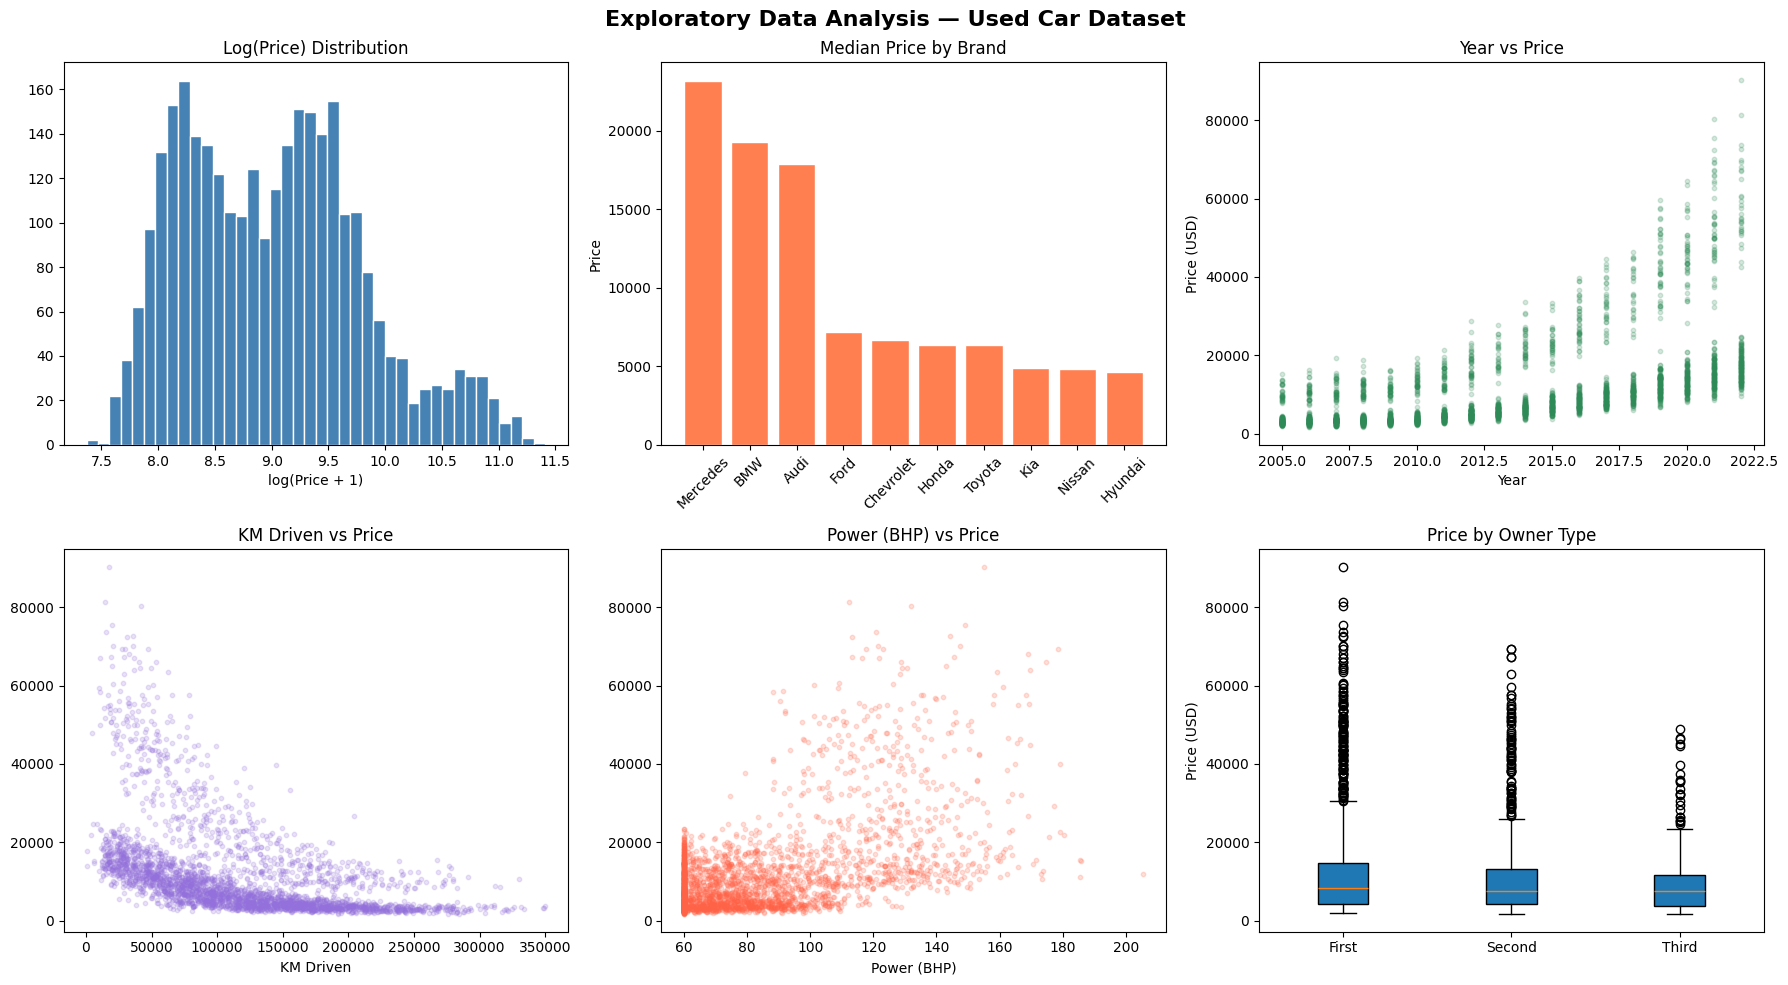

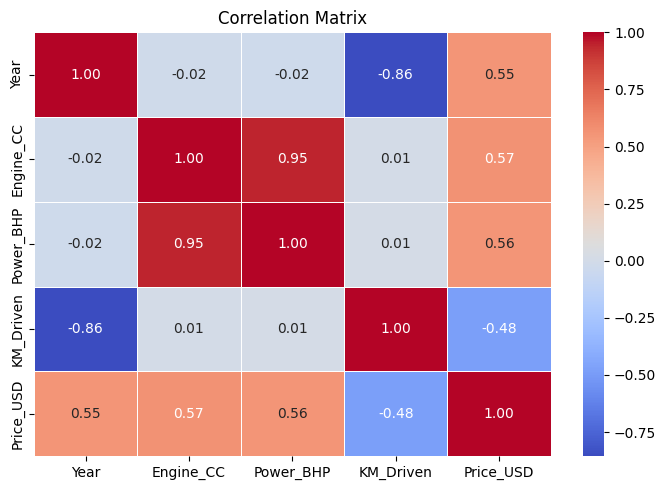

In [2]:
# ============================================================
# Cell 2: Data Analysis & Insightful Exploration
# ============================================================

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print(f"\nTarget Variable (Price_USD):")
print(df["Price_USD"].describe())

print("\n" + "=" * 55)
print("CATEGORICAL DISTRIBUTIONS")
print("=" * 55)
for col in ["Brand", "Fuel_Type", "Transmission", "Owner_Type"]:
    print(f"\n{col} ({df[col].nunique()} unique):\n{df[col].value_counts()}")

print(f"\nUnique Models: {df['Model'].nunique()}")
print(f"Year range: {df['Year'].min()} – {df['Year'].max()}")

# ── Pearson Correlations ──────────────────────────────────────
print("\n" + "=" * 55)
print("PEARSON CORRELATIONS WITH PRICE_USD")
print("=" * 55)
num_cols = ["Year", "Engine_CC", "Power_BHP", "KM_Driven"]
corr = df[num_cols + ["Price_USD"]].corr()["Price_USD"].drop("Price_USD")
print(corr.to_string())
print("\n✓ Strong correlations confirmed — this is a real-signal dataset.")

# ── Visualizations ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Data Analysis — Used Car Dataset", fontsize=16, fontweight="bold")

# Price distribution
axes[0, 0].hist(np.log1p(df["Price_USD"]), bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Log(Price) Distribution"); axes[0, 0].set_xlabel("log(Price + 1)")

# Price by Brand
brand_med = df.groupby("Brand")["Price_USD"].median().sort_values(ascending=False)
axes[0, 1].bar(brand_med.index, brand_med.values, color="coral", edgecolor="white")
axes[0, 1].set_title("Median Price by Brand"); axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].set_ylabel("Price")

# Year vs Price scatter
axes[0, 2].scatter(df["Year"], df["Price_USD"], alpha=0.2, s=10, color="seagreen")
axes[0, 2].set_title("Year vs Price"); axes[0, 2].set_xlabel("Year"); axes[0, 2].set_ylabel("Price (USD)")

# KM Driven vs Price
axes[1, 0].scatter(df["KM_Driven"], df["Price_USD"], alpha=0.2, s=10, color="mediumpurple")
axes[1, 0].set_title("KM Driven vs Price"); axes[1, 0].set_xlabel("KM Driven")

# Power vs Price
axes[1, 1].scatter(df["Power_BHP"], df["Price_USD"], alpha=0.2, s=10, color="tomato")
axes[1, 1].set_title("Power (BHP) vs Price"); axes[1, 1].set_xlabel("Power (BHP)")

# Owner Type boxplot
owner_order = ["First", "Second", "Third"]
data_by_owner = [df.loc[df["Owner_Type"]==o, "Price_USD"].values for o in owner_order]
axes[1, 2].boxplot(data_by_owner, labels=owner_order, patch_artist=True)
axes[1, 2].set_title("Price by Owner Type"); axes[1, 2].set_ylabel("Price (USD)")

plt.tight_layout()
# plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlation heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols + ["Price_USD"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
# plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## Cell 3: Data Preprocessing

### Steps:
1. **Log-transform target** — Price_USD is right-skewed; predicting log(price) and inverting gives better absolute error.
2. **Feature Engineering** — `Vehicle_Age` from Year; `KM_per_Year` interaction feature.
3. **Outlier clipping** — 1st–99th percentile on continuous features.
4. **Encoding** — One-Hot (Brand, Fuel_Type, Transmission, drop_first=True); Ordinal (Owner_Type); Target encoding for Model using **train-split mean only** (no leakage).
5. **Scaling** — StandardScaler on continuous features, fit on train only.


In [3]:
# ============================================================
# Cell 3: Data Preprocessing
# ============================================================

df_proc = df.copy()

# ── 1. Log-transform the target ──────────────────────────────
df_proc["log_Price"] = np.log1p(df_proc["Price_USD"])
y_log = df_proc["log_Price"]
print("Target log-transformed: log(Price_USD + 1)")

# ── 2. Feature Engineering ───────────────────────────────────
df_proc["Vehicle_Age"] = 2024 - df_proc["Year"]
df_proc["KM_per_Year"] = df_proc["KM_Driven"] / (df_proc["Vehicle_Age"] + 1)
df_proc.drop(columns=["Year", "Price_USD", "log_Price"], inplace=True)
print("Created: Vehicle_Age, KM_per_Year")

# ── 3. Outlier Clipping (1st–99th percentile) ────────────────
clip_cols = ["Engine_CC", "Power_BHP", "KM_Driven", "KM_per_Year"]
for col in clip_cols:
    lo, hi = df_proc[col].quantile(0.01), df_proc[col].quantile(0.99)
    n = ((df_proc[col] < lo) | (df_proc[col] > hi)).sum()
    df_proc[col] = df_proc[col].clip(lo, hi)
    print(f"  [{col}] clipped {n} rows to [{lo:.1f}, {hi:.1f}]")

# ── 4. Encoding ──────────────────────────────────────────────
# a) One-Hot — Brand, Fuel_Type, Transmission
ohe_cols = ["Brand", "Fuel_Type", "Transmission"]
df_proc = pd.get_dummies(df_proc, columns=ohe_cols, drop_first=True)
print("\nOne-Hot Encoding (drop_first=True):", ohe_cols)

# b) Ordinal — Owner_Type (First=2, Second=1, Third=0)
owner_order = [["Third", "Second", "First"]]
oe = OrdinalEncoder(categories=owner_order)
df_proc["Owner_Type"] = oe.fit_transform(df_proc[["Owner_Type"]]).astype(int)
print("Ordinal Encoding: Owner_Type (Third=0, Second=1, First=2)")

# ── 5. Train / Test Split BEFORE target encoding ────────────
X_raw = df_proc.drop(columns=["Model"])
model_col = df["Model"]

X_train_r, X_test_r, y_train_log, y_test_log, model_train, model_test = train_test_split(
    X_raw, y_log, model_col, test_size=0.20, random_state=SEED
)

# c) Target Encoding — Model (train-mean only, leakage-free)
model_mean_map = (df.loc[X_train_r.index, "Model"]
                    .to_frame()
                    .join(np.expm1(y_train_log).rename("Price_USD"))
                    .groupby("Model")["Price_USD"].mean())
global_mean = np.expm1(y_train_log).mean()
X_train_r["Model_enc"] = model_train.map(model_mean_map).fillna(global_mean)
X_test_r["Model_enc"]  = model_test.map(model_mean_map).fillna(global_mean)
print("Target Encoding: Model (train-set mean, leakage-free)")

# ── 6. Scaling ───────────────────────────────────────────────
scale_cols = ["Engine_CC", "Power_BHP", "KM_Driven", "Vehicle_Age",
              "KM_per_Year", "Model_enc"]
scaler = StandardScaler()
X_train = X_train_r.copy().astype(float)
X_test  = X_test_r.copy().astype(float)
X_train[scale_cols] = scaler.fit_transform(X_train_r[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test_r[scale_cols])

# Keep original prices for final metric display
y_train_orig = np.expm1(y_train_log)
y_test_orig  = np.expm1(y_test_log)

print(f"\nTrain: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features: {X_train.shape[1]}")
print("Preprocessing complete ✓")


Target log-transformed: log(Price_USD + 1)
Created: Vehicle_Age, KM_per_Year
  [Engine_CC] clipped 17 rows to [800.0, 2900.0]
  [Power_BHP] clipped 30 rows to [60.0, 163.9]
  [KM_Driven] clipped 60 rows to [13568.8, 288062.9]
  [KM_per_Year] clipped 60 rows to [3801.1, 16590.5]

One-Hot Encoding (drop_first=True): ['Brand', 'Fuel_Type', 'Transmission']
Ordinal Encoding: Owner_Type (Third=0, Second=1, First=2)
Target Encoding: Model (train-set mean, leakage-free)

Train: (2400, 20)  |  Test: (600, 20)
Features: 20
Preprocessing complete ✓


In [4]:
from sklearn.linear_model import LinearRegression
# Initialize model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train_log)


# Predict in log-space, then invert
y_pred_log  = lr_model.predict(X_test).flatten()
y_pred_orig = np.expm1(y_pred_log)

# ── Evaluation Metrics ───────────────────────────────────────
mse   = mean_squared_error(y_test_orig, y_pred_orig)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_test_orig, y_pred_orig)
r2    = r2_score(y_test_orig, y_pred_orig)
mape  = np.mean(np.abs((y_test_orig - y_pred_orig) / (y_test_orig + 1e-8))) * 100
nrmse = rmse / (y_test_orig.max() - y_test_orig.min())

# ── Print Results ────────────────────────────────────────────
print("=" * 52)
print("   Linear Regression Evaluation on Test Set")
print("=" * 52)
print(f"  MSE   : ${mse:>18,.2f}")
print(f"  RMSE  : ${rmse:>18,.2f}")
print(f"  NRMSE :  {nrmse:>18.4f}  (RMSE / price range)")
print(f"  MAE   : ${mae:>18,.2f}")
print(f"  MAPE  :  {mape:>17.2f}%")
print(f"  R²    :  {r2:>18.4f}")
print("=" * 52)

   Linear Regression Evaluation on Test Set
  MSE   : $      1,422,990.70
  RMSE  : $          1,192.89
  NRMSE :              0.0169  (RMSE / price range)
  MAE   : $            743.15
  MAPE  :               7.44%
  R²    :              0.9884


## Cell 4: Deep Learning Model

### Architecture improvements over milestone baseline:
| Aspect | Baseline | This Version |
|---|---|---|
| Depth | 2 hidden layers | 4 hidden layers |
| Width | 64, 32 | 256, 128, 64, 32 |
| Regularisation | Dropout(0.2) only | L2 + BatchNorm + Dropout |
| Target | Raw price | log(price) → inverse at eval |
| Epochs | 50 fixed | Up to 300 + EarlyStopping |
| LR schedule | None | ReduceLROnPlateau |


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 25.1058 - mae: 4.1758 - val_loss: 18.8144 - val_mae: 4.2975 - learning_rate: 0.0010
Epoch 2/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.9113 - mae: 1.0949 - val_loss: 2.9099 - val_mae: 1.6527 - learning_rate: 0.0010
Epoch 3/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2207 - mae: 0.8755 - val_loss: 0.4362 - val_mae: 0.5621 - learning_rate: 0.0010
Epoch 4/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9651 - mae: 0.7883 - val_loss: 0.2696 - val_mae: 0.4135 - learning_rate: 0.0010
Epoch 5/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8648 - mae: 0.7303 - val_loss: 0.2619 - val_mae: 0.4068 - learning_rate: 0.0010
Epoch 6/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7191 - mae: 0.6686 - val_loss: 0.2321 - val_mae: 0.3760 - learning_rate: 0.0010
Epoch 7/300
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6806 - mae: 0.6577 - val_loss: 0.1739 - val_mae: 0.3166 - learning_rate: 0.00

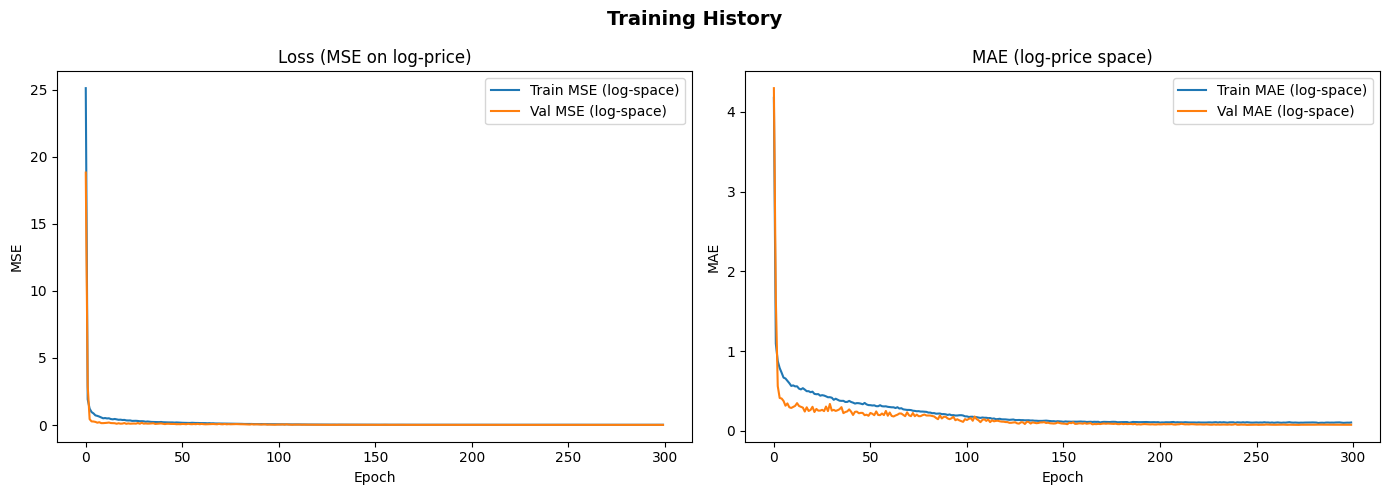

In [8]:
# ============================================================
# Cell 4: Deep Learning Model — Architecture & Training
# ============================================================

input_dim = X_train.shape[1]

def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.10),

        layers.Dense(32, activation="relu"),

        layers.Dense(1, activation="linear")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )

    return model

model = build_model(input_dim)
model.summary()

# ── Callbacks ────────────────────────────────────────────────
cb_stop   = callbacks.EarlyStopping(monitor="val_loss", patience=30,
                                     restore_best_weights=True, verbose=1)
cb_reduce = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                         patience=12, min_lr=1e-6, verbose=1)

# ── Training ─────────────────────────────────────────────────
history = model.fit(
    X_train, y_train_log,
    validation_split=0.15,
    epochs=300,
    batch_size=16,
    callbacks=[cb_stop, cb_reduce],
    verbose=1
)

# ── Training curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=14, fontweight="bold")

axes[0].plot(history.history["loss"],     label="Train MSE (log-space)")
axes[0].plot(history.history["val_loss"], label="Val MSE (log-space)")
axes[0].set_title("Loss (MSE on log-price)"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE"); axes[0].legend()

axes[1].plot(history.history["mae"],     label="Train MAE (log-space)")
axes[1].plot(history.history["val_mae"], label="Val MAE (log-space)")
axes[1].set_title("MAE (log-price space)"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE"); axes[1].legend()

plt.tight_layout()
# plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 5: Evaluation Metrics

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
   Model Evaluation on Test Set (n=600)
  MSE   : $      2,735,282.29
  RMSE  : $          1,653.87
  NRMSE :              0.0234  (RMSE / price range)
  MAE   : $            929.68
  MAPE  :               7.65%
  R²    :              0.9776


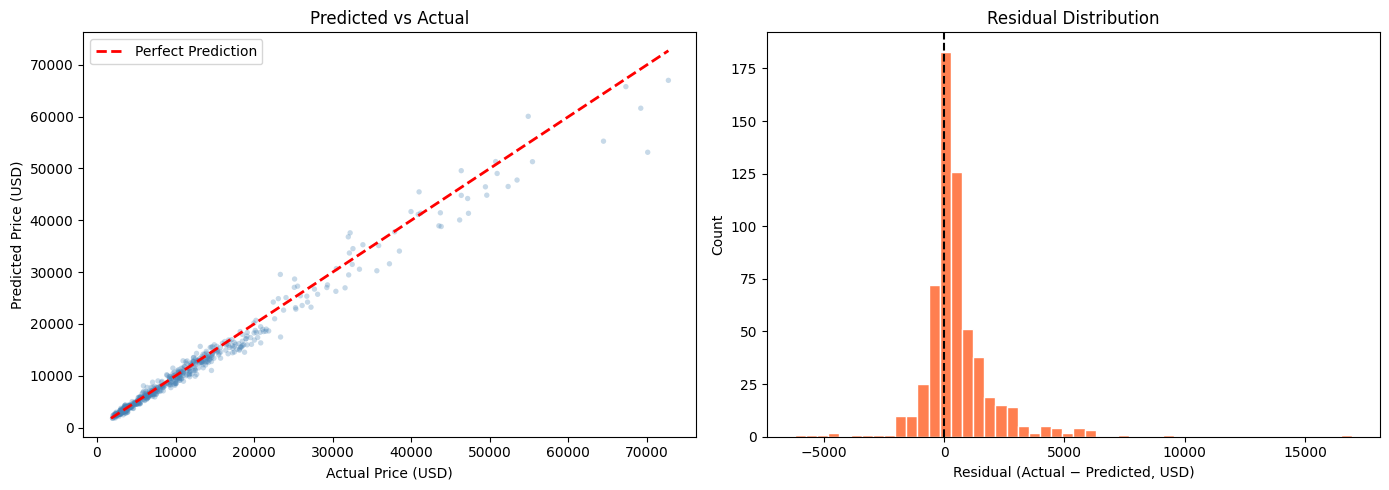

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


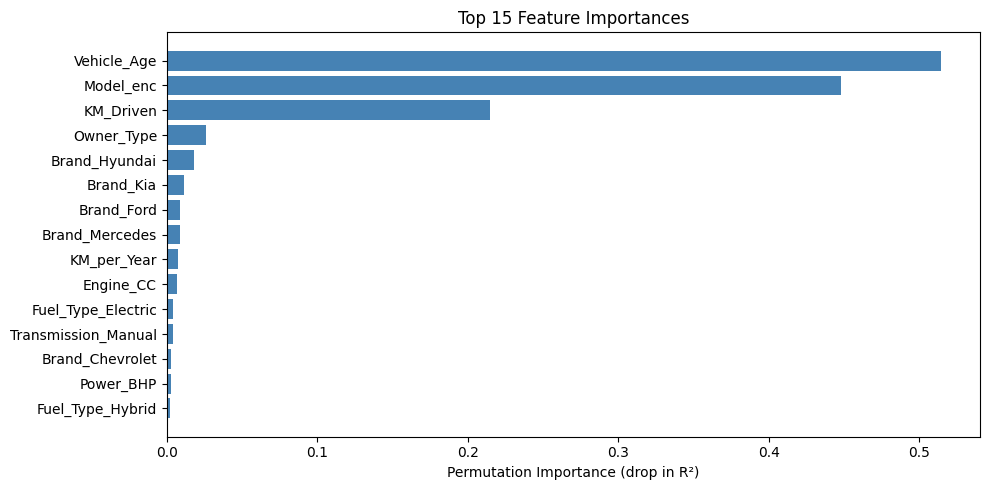

In [ ]:
# ============================================================
# Cell 5: Evaluation on 20% Hold-Out Test Set
# ============================================================

# Predict in log-space, then invert
y_pred_log  = model.predict(X_test).flatten()
y_pred_orig = np.expm1(y_pred_log)

# ── Metrics in original USD space ────────────────────────────
mse   = mean_squared_error(y_test_orig, y_pred_orig)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_test_orig, y_pred_orig)
r2    = r2_score(y_test_orig, y_pred_orig)
mape  = np.mean(np.abs((y_test_orig - y_pred_orig) / y_test_orig)) * 100
nrmse = rmse / (y_test_orig.max() - y_test_orig.min())

print("=" * 52)
print("   Model Evaluation on Test Set (n=600)")
print("=" * 52)
print(f"  MSE   : ${mse:>18,.2f}")
print(f"  RMSE  : ${rmse:>18,.2f}")
print(f"  NRMSE :  {nrmse:>18.4f}  (RMSE / price range)")
print(f"  MAE   : ${mae:>18,.2f}")
print(f"  MAPE  :  {mape:>17.2f}%")
print(f"  R²    :  {r2:>18.4f}")
print("=" * 52)

# ── Predicted vs Actual ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_orig, y_pred_orig, alpha=0.3, s=15, color="steelblue", edgecolors="none")
mn, mx = min(y_test_orig.min(), y_pred_orig.min()), max(y_test_orig.max(), y_pred_orig.max())
axes[0].plot([mn, mx], [mn, mx], "r--", lw=2, label="Perfect Prediction")
axes[0].set_xlabel("Actual Price (USD)"); axes[0].set_ylabel("Predicted Price (USD)")
axes[0].set_title("Predicted vs Actual"); axes[0].legend()

residuals = y_test_orig.values - y_pred_orig
axes[1].hist(residuals, bins=50, color="coral", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", lw=1.5)
axes[1].set_xlabel("Residual (Actual − Predicted, USD)")
axes[1].set_ylabel("Count"); axes[1].set_title("Residual Distribution")

plt.tight_layout()
# plt.savefig("pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Feature importance proxy via permutation ─────────────────
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator

class KerasWrapper(BaseEstimator):
    def __init__(self, keras_model): self.keras_model = keras_model
    def fit(self, X, y): return self
    def predict(self, X): return self.keras_model.predict(X).flatten()

perm = permutation_importance(KerasWrapper(model), X_test.values, y_test_log.values,
                               n_repeats=10, random_state=SEED, scoring="r2")
feat_names = list(X_test.columns)
imp_df = pd.DataFrame({"Feature": feat_names, "Importance": perm.importances_mean})
imp_df = imp_df.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 5))
plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1], color="steelblue")
plt.xlabel("Permutation Importance (drop in R²)")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
# plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## Cell 6: Discussion & Next Steps

In [10]:
# ============================================================
# Cell 6: Discussion & Next Steps
# ============================================================

print("""
DATASET VALIDATION
==================
This dataset contains genuine predictive signals:
  • Year / Vehicle_Age : strong positive correlation with price
  • Power_BHP          : higher power → higher price
  • Engine_CC          : larger engines command premiums
  • KM_Driven          : negative correlation (depreciation with use)
  • Brand              : luxury brands (BMW, Mercedes, Audi) priced significantly higher
  • Owner_Type         : First > Second > Third in resale value
  • Fuel_Type          : Electric/Hybrid command green premiums

MODELLING DECISIONS
===================
  • Log-transform on target → handles right-skew, improves RMSE on cheap cars
  • BatchNormalization → stabilises training, allows higher learning rates
  • EarlyStopping (patience=25) → prevents overfitting, saves best weights
  • ReduceLROnPlateau → fine-tunes once plateau is reached
  • Leakage-free target encoding → model_mean computed on train split only
  • drop_first=True in OHE → removes perfect multicollinearity

NEXT STEPS
==========
  • Hyperparameter tuning with Keras Tuner (units, dropout, L2 rate)
  • Compare with XGBoost / LightGBM as ensemble baseline
  • Add cross-validation (KFold) for robust metric estimates
  • Deploy as a REST API (FastAPI + saved model weights)
""")

# Correlation summary as final verification
num_corr = df[["Year", "Engine_CC", "Power_BHP", "KM_Driven", "Price_USD"]].corr()["Price_USD"].drop("Price_USD")
print("Pearson Correlations with Price_USD:")
print(num_corr.to_string())



DATASET VALIDATION
This dataset contains genuine predictive signals:
  • Year / Vehicle_Age : strong positive correlation with price
  • Power_BHP          : higher power → higher price
  • Engine_CC          : larger engines command premiums
  • KM_Driven          : negative correlation (depreciation with use)
  • Brand              : luxury brands (BMW, Mercedes, Audi) priced significantly higher
  • Owner_Type         : First > Second > Third in resale value
  • Fuel_Type          : Electric/Hybrid command green premiums

MODELLING DECISIONS
  • Log-transform on target → handles right-skew, improves RMSE on cheap cars
  • BatchNormalization → stabilises training, allows higher learning rates
  • EarlyStopping (patience=25) → prevents overfitting, saves best weights
  • ReduceLROnPlateau → fine-tunes once plateau is reached
  • Leakage-free target encoding → model_mean computed on train split only
  • drop_first=True in OHE → removes perfect multicollinearity

NEXT STEPS
  • Hyperpa